# OBD Article Plots

This notebook generates the article-oriented figures directly from the saved experiment artifacts.

Covered figures:

1. Semantic-quality landscape for the desktop runs.
2. Desktop resource fingerprint.
3. LLM-as-a-judge radar profile.
4. Raspberry Pi 5 resource-focused inference plot.

All plots are rendered from the notebook itself and saved under `results/article_plots/`.

In [10]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.patches import Ellipse

CWD = Path.cwd().resolve()
PROJECT_ROOT = next((path for path in (CWD, *CWD.parents) if (path / 'pyproject.toml').exists()), CWD)
ARTICLE_PLOT_DIR = PROJECT_ROOT / 'results' / 'article_plots'
ARTICLE_PLOT_DIR.mkdir(parents=True, exist_ok=True)

APPROACH_COLORS = {
    'Soft Prompt': '#C44E52',
    'Flamingo': '#4C72B0',
}

FAMILY_MARKERS = {
    'Gemma 3 270M': 'o',
    'Llama 3.2 1B': 's',
}

SYSTEM_LABELS = {
    'gemma_soft_prompt': 'Gemma + Soft Prompt',
    'gemma_flamingo': 'Gemma + Flamingo',
    'llama_soft_prompt': 'Llama + Soft Prompt',
    'llama_flamingo': 'Llama + Flamingo',
}

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'semibold'
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#FBFBF8'
plt.rcParams['grid.color'] = '#D9D9D0'
plt.rcParams['grid.alpha'] = 0.55

def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open('r', encoding='utf-8') as handle:
        for line in handle:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def bytes_to_gib(value):
    return None if value is None else float(value) / (1024 ** 3)

def add_covariance_ellipse(ax, x: pd.Series, y: pd.Series, color: str) -> None:
    points = np.column_stack([x.to_numpy(dtype=float), y.to_numpy(dtype=float)])
    if len(points) < 3:
        return
    cov = np.cov(points, rowvar=False)
    if np.linalg.det(cov) <= 0:
        return
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2.2 * np.sqrt(eigenvalues)
    ellipse = Ellipse(
        xy=points.mean(axis=0),
        width=width,
        height=height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=0.08,
        linewidth=1.4,
    )
    ax.add_patch(ellipse)

def draw_ecdf(ax, values: pd.Series, *, color: str, label: str, linestyle: str) -> None:
    arr = np.sort(values.dropna().to_numpy(dtype=float))
    if arr.size == 0:
        return
    y = np.arange(1, arr.size + 1) / arr.size
    ax.step(arr, y, where='post', color=color, linewidth=2.4, linestyle=linestyle, label=label)


## 1. Semantic Quality Landscape

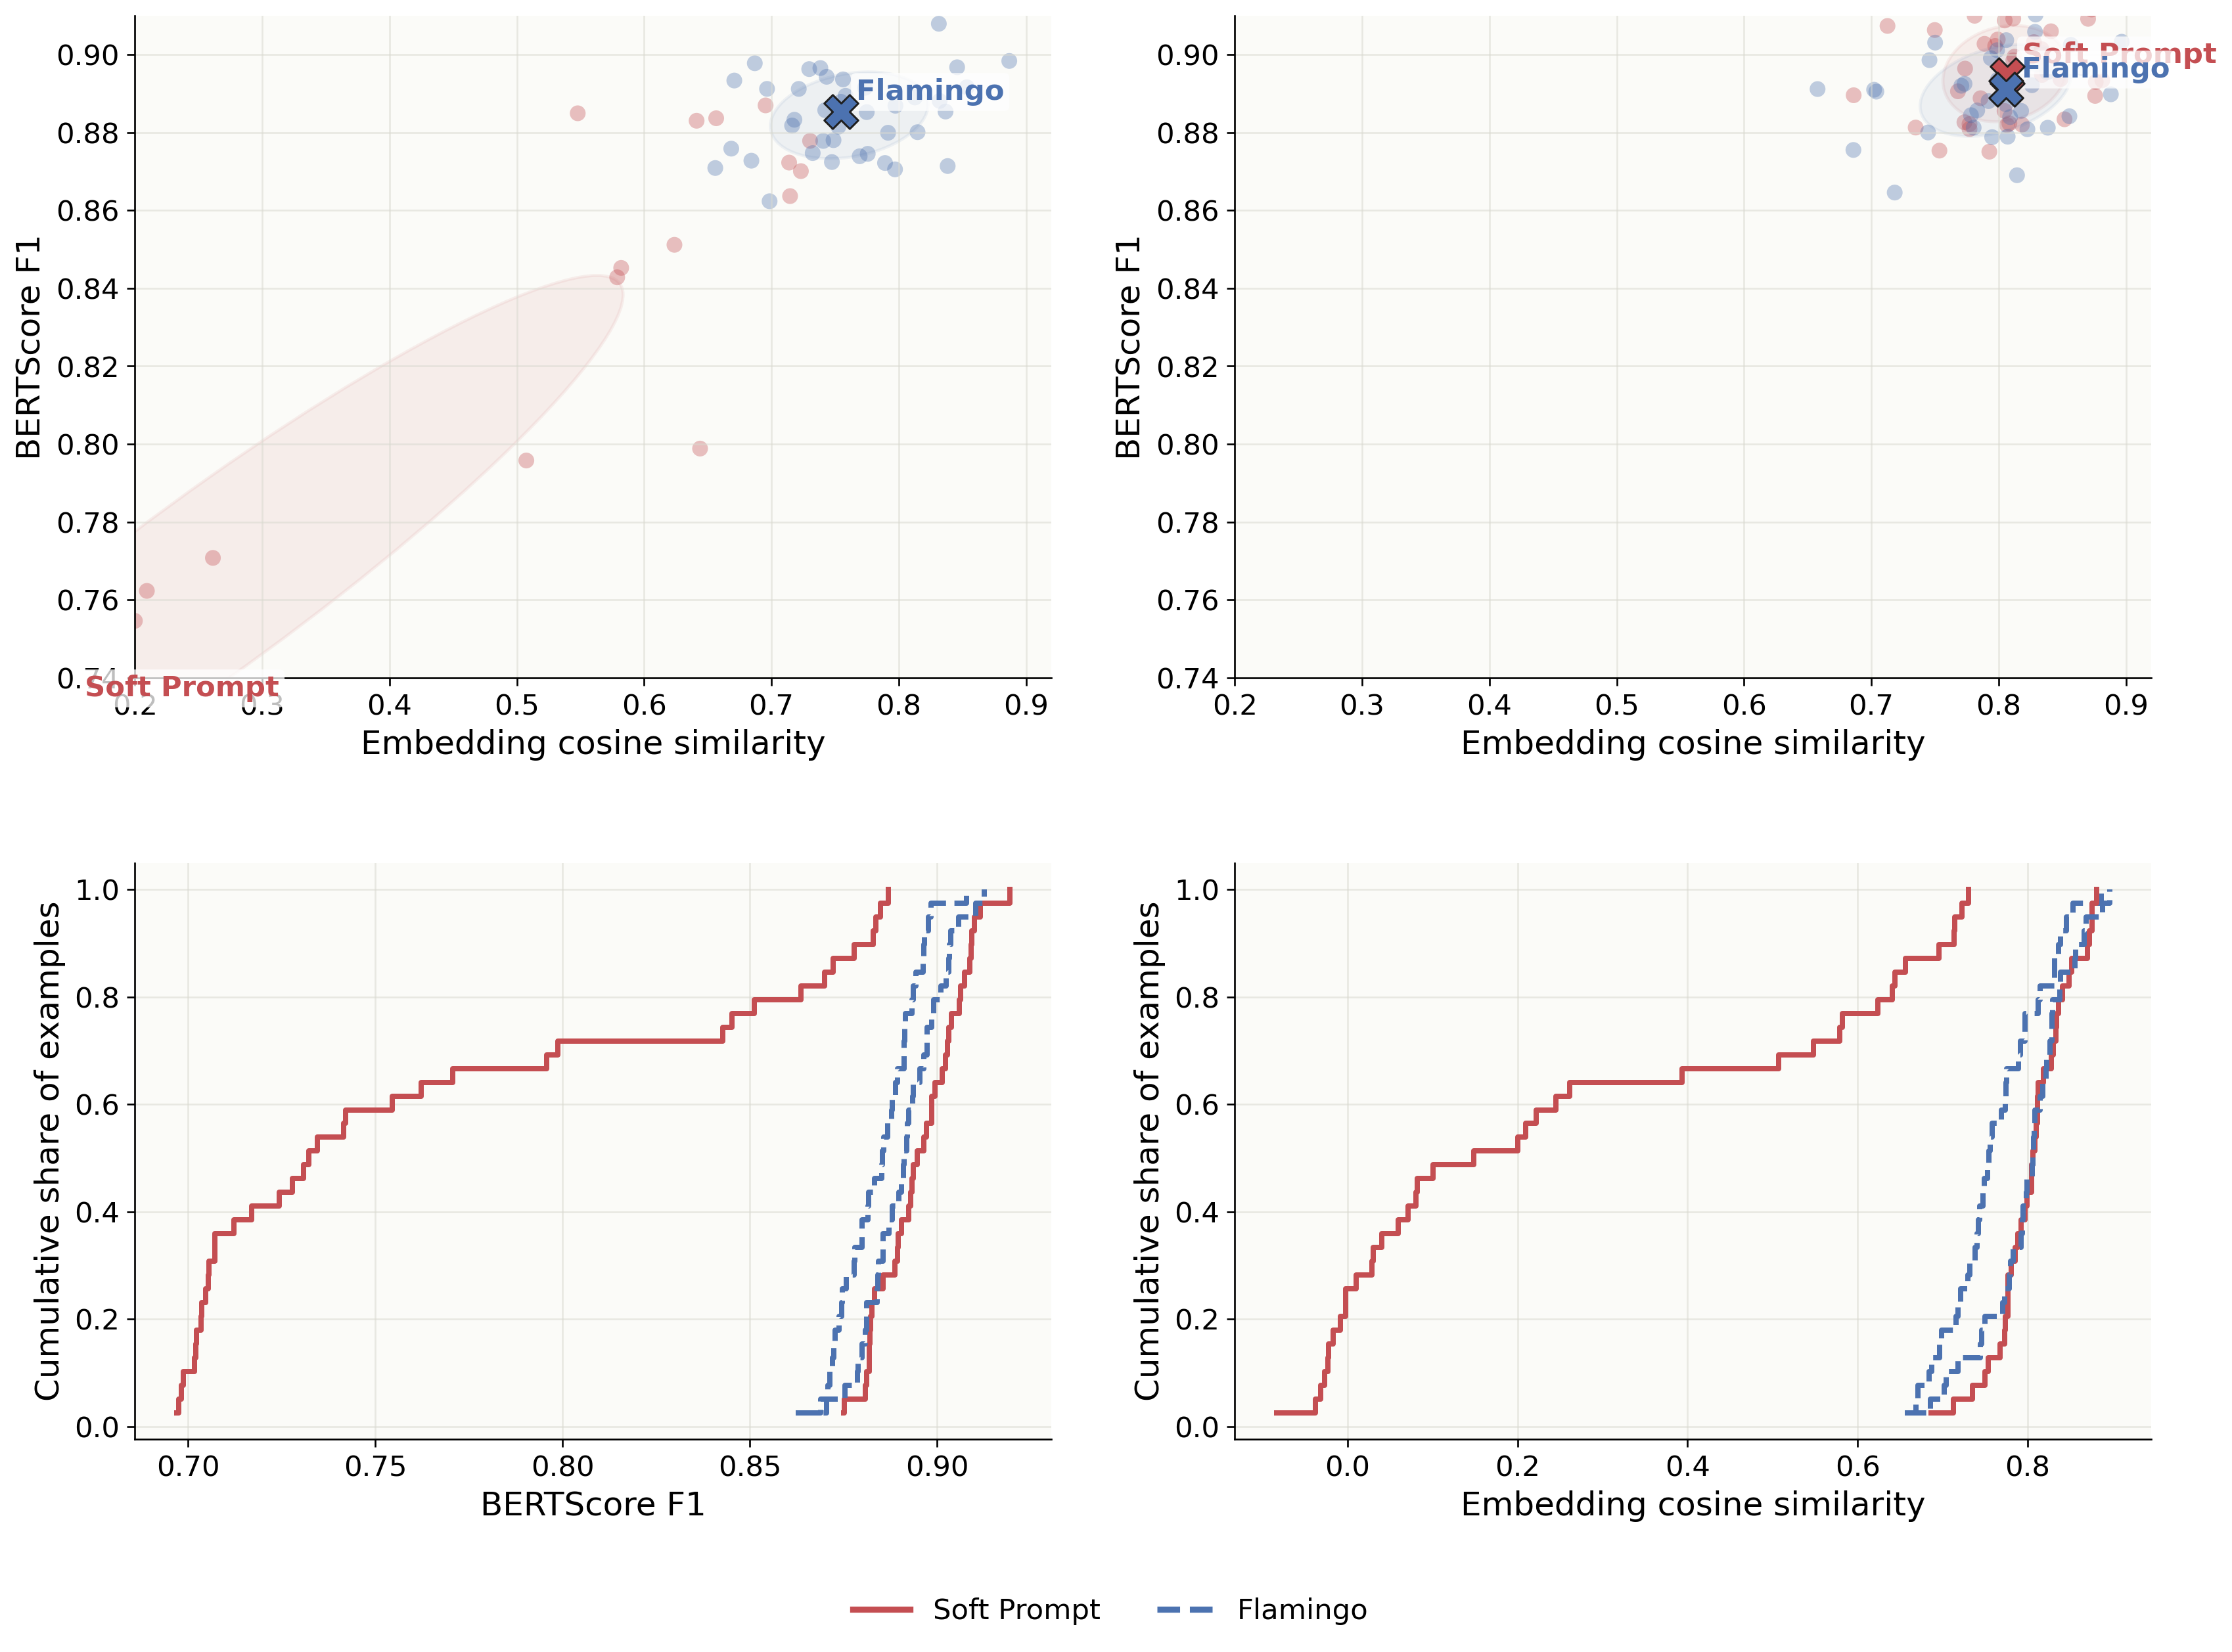

PosixPath('/Users/morsinaldo/Desktop/METROAUTOMOTIVE2026-AutoTSLM/results/article_plots/obd_semantic_landscape.png')

In [11]:
SEMANTIC_RUNS = [
    {
        'display_name': 'Gemma + Soft Prompt',
        'family': 'Gemma 3 270M',
        'approach': 'Soft Prompt',
        'detail_path': PROJECT_ROOT / 'data' / 'obd_eval_detailed_gemma3_270m.jsonl',
    },
    {
        'display_name': 'Gemma + Flamingo',
        'family': 'Gemma 3 270M',
        'approach': 'Flamingo',
        'detail_path': PROJECT_ROOT / 'data' / 'obd_alignment_test_detailed_gemma3_270m.jsonl',
    },
    {
        'display_name': 'Llama + Soft Prompt',
        'family': 'Llama 3.2 1B',
        'approach': 'Soft Prompt',
        'detail_path': PROJECT_ROOT / 'data' / 'obd_eval_detailed_llama3_2_1B.jsonl',
    },
    {
        'display_name': 'Llama + Flamingo',
        'family': 'Llama 3.2 1B',
        'approach': 'Flamingo',
        'detail_path': PROJECT_ROOT / 'data' / 'obd_alignment_test_detailed_llama3_2_1B.jsonl',
    },
]

frames = []
for run in SEMANTIC_RUNS:
    df = pd.DataFrame(read_jsonl(run['detail_path']))
    df['display_name'] = run['display_name']
    df['family'] = run['family']
    df['approach'] = run['approach']
    frames.append(df)

semantic_df = pd.concat(frames, ignore_index=True)
for col in ['bertscore_f1', 'embedding_cosine', 'token_f1', 'rouge_l_f1']:
    semantic_df[col] = pd.to_numeric(semantic_df[col], errors='coerce')

fig = plt.figure(figsize=(16.5, 12.2))
grid = fig.add_gridspec(2, 2, height_ratios=[1.15, 1.0], hspace=0.30, wspace=0.20)
metric_axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])]
bert_ax = fig.add_subplot(grid[1, 0])
cosine_ax = fig.add_subplot(grid[1, 1])

for ax, family in zip(metric_axes, ['Gemma 3 270M', 'Llama 3.2 1B']):
    family_df = semantic_df[semantic_df['family'] == family].copy()
    for display_name in ['Gemma + Soft Prompt', 'Gemma + Flamingo', 'Llama + Soft Prompt', 'Llama + Flamingo']:
        subset = family_df[family_df['display_name'] == display_name]
        if subset.empty:
            continue
        color = APPROACH_COLORS[subset['approach'].iloc[0]]
        ax.scatter(subset['embedding_cosine'], subset['bertscore_f1'], s=52, alpha=0.35, color=color, edgecolor='none')
        add_covariance_ellipse(ax, subset['embedding_cosine'], subset['bertscore_f1'], color)
        center_x = subset['embedding_cosine'].median()
        center_y = subset['bertscore_f1'].median()
        ax.scatter([center_x], [center_y], s=240, marker='X', color=color, edgecolor='#1F1F1F', linewidth=0.9, zorder=5)
        ax.text(center_x + 0.012, center_y + 0.003, subset['approach'].iloc[0], fontsize=13, color=color, weight='semibold', bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.75))
    ax.set_xlabel('Embedding cosine similarity', fontsize=15)
    ax.set_ylabel('BERTScore F1', fontsize=15)
    ax.set_xlim(0.2, 0.92)
    ax.set_ylim(0.74, 0.91)
    ax.tick_params(labelsize=13)

for display_name in ['Gemma + Soft Prompt', 'Gemma + Flamingo', 'Llama + Soft Prompt', 'Llama + Flamingo']:
    subset = semantic_df[semantic_df['display_name'] == display_name]
    color = APPROACH_COLORS[subset['approach'].iloc[0]]
    linestyle = '-' if 'Soft Prompt' in display_name else '--'
    draw_ecdf(bert_ax, subset['bertscore_f1'], color=color, label=display_name, linestyle=linestyle)
    draw_ecdf(cosine_ax, subset['embedding_cosine'], color=color, label=display_name, linestyle=linestyle)

bert_ax.set_xlabel('BERTScore F1', fontsize=15)
bert_ax.set_ylabel('Cumulative share of examples', fontsize=15)
bert_ax.tick_params(labelsize=13)

cosine_ax.set_xlabel('Embedding cosine similarity', fontsize=15)
cosine_ax.set_ylabel('Cumulative share of examples', fontsize=15)
cosine_ax.tick_params(labelsize=13)

semantic_handles = [
    plt.Line2D([0], [0], color=APPROACH_COLORS['Soft Prompt'], linestyle='-', linewidth=2.8, label='Soft Prompt'),
    plt.Line2D([0], [0], color=APPROACH_COLORS['Flamingo'], linestyle='--', linewidth=2.8, label='Flamingo'),
]
fig.legend(handles=semantic_handles, loc='lower center', bbox_to_anchor=(0.5, 0.03), ncol=2, frameon=False, fontsize=13)
fig.subplots_adjust(bottom=0.14)

semantic_plot_path = ARTICLE_PLOT_DIR / 'obd_semantic_landscape.png'
fig.savefig(semantic_plot_path, dpi=240, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(semantic_plot_path)))
semantic_plot_path

## 2. Desktop Resource Fingerprint

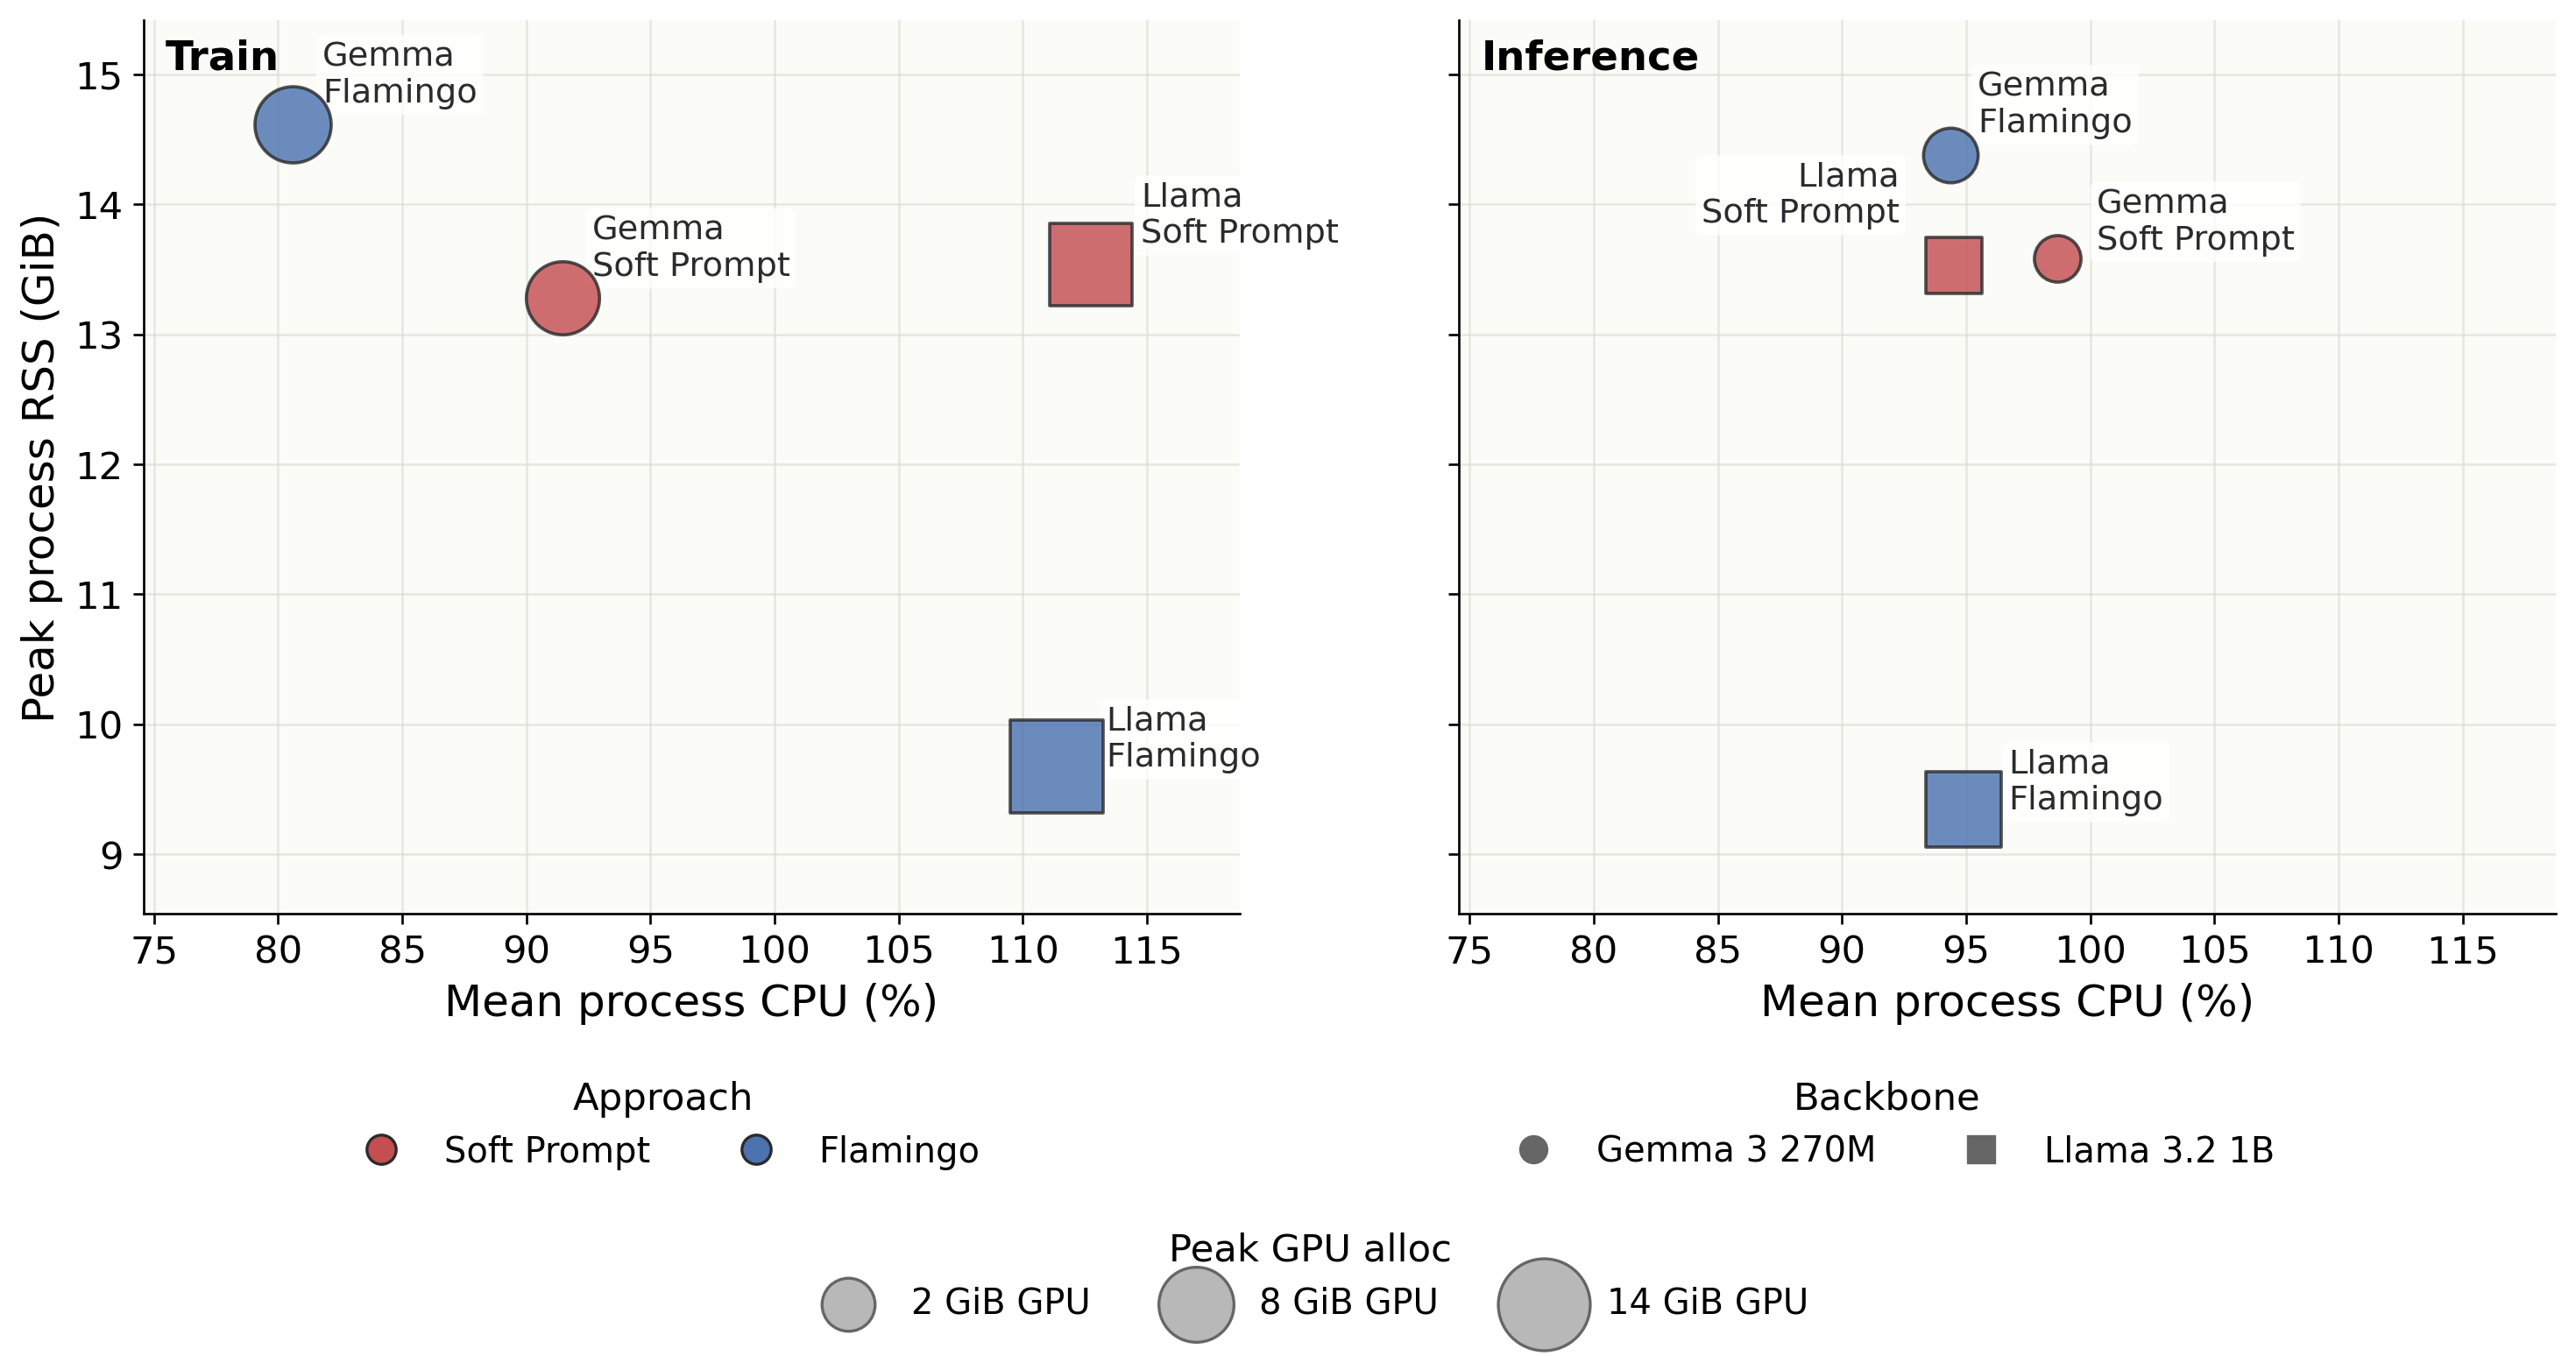

PosixPath('/Users/morsinaldo/Desktop/METROAUTOMOTIVE2026-AutoTSLM/results/article_plots/obd_resource_fingerprint.png')

In [12]:
RESOURCE_RUNS = [
    {'display_name': 'Gemma + Soft Prompt', 'family': 'Gemma 3 270M', 'approach': 'Soft Prompt', 'prefix': 'obd_soft_prompt_gemma_3_270m'},
    {'display_name': 'Gemma + Flamingo', 'family': 'Gemma 3 270M', 'approach': 'Flamingo', 'prefix': 'obd_flamingo_gemma_3_270m'},
    {'display_name': 'Llama + Soft Prompt', 'family': 'Llama 3.2 1B', 'approach': 'Soft Prompt', 'prefix': 'obd_soft_prompt_llama_3_2_1b'},
    {'display_name': 'Llama + Flamingo', 'family': 'Llama 3.2 1B', 'approach': 'Flamingo', 'prefix': 'obd_flamingo_llama_3_2_1b'},
]

metrics_dir = PROJECT_ROOT / 'results' / 'notebook_metrics'
resource_rows = []
for run in RESOURCE_RUNS:
    for phase in ('train', 'inference'):
        summary = json.loads((metrics_dir / f"{run['prefix']}_{phase}_summary.json").read_text(encoding='utf-8'))
        resource_rows.append({
            'display_name': run['display_name'],
            'family': run['family'],
            'approach': run['approach'],
            'phase': phase,
            'duration_min': summary['total_duration_s'] / 60.0,
            'peak_gpu_alloc_gib': bytes_to_gib(summary.get('cuda_0_max_memory_allocated_bytes_max')),
            'peak_rss_gib': bytes_to_gib(summary.get('process_rss_bytes_max')),
            'mean_process_cpu_percent': summary.get('process_cpu_percent_mean'),
        })

resource_df = pd.DataFrame(resource_rows)
ordered_labels = ['Gemma + Soft Prompt', 'Gemma + Flamingo', 'Llama + Soft Prompt', 'Llama + Flamingo']

desktop_label_positions = {
    ('Gemma + Soft Prompt', 'train'): (1.2, 0.12, 'left'),
    ('Gemma + Flamingo', 'train'): (1.2, 0.12, 'left'),

    ('Llama + Soft Prompt', 'train'): (2.0, 0.12, 'left'),
    ('Llama + Flamingo', 'train'): (2.0, -0.05, 'left'),

    ('Gemma + Soft Prompt', 'inference'): (1.6, 0.02, 'left'),
    ('Gemma + Flamingo', 'inference'): (1.1, 0.12, 'left'),

    ('Llama + Soft Prompt', 'inference'): (-2.2, 0.28, 'right'),
    ('Llama + Flamingo', 'inference'): (1.8, -0.05, 'left'),
}

fig, axes = plt.subplots(1, 2, figsize=(14.8, 7.2), sharey=True)
for ax, phase in zip(axes, ['train', 'inference']):
    phase_df = resource_df[resource_df['phase'] == phase].copy().set_index('display_name').loc[ordered_labels].reset_index()
    for row in phase_df.itertuples(index=False):
        color = APPROACH_COLORS[row.approach]
        marker = FAMILY_MARKERS[row.family]
        bubble_size = 220 + 55 * float(row.peak_gpu_alloc_gib or 0.0)
        ax.scatter(row.mean_process_cpu_percent, row.peak_rss_gib, s=bubble_size, color=color, marker=marker, alpha=0.82, edgecolor='#2B2B2B', linewidth=1.1, zorder=4)
        dx, dy, ha = desktop_label_positions[(row.display_name, phase)]
        ax.text(row.mean_process_cpu_percent + dx, row.peak_rss_gib + dy, row.display_name.replace(' + ', '\n'), fontsize=11.5, color='#2B2B2B', ha=ha, va='bottom', bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.80))
    ax.set_xlabel('Mean process CPU (%)', fontsize=15)
    ax.tick_params(labelsize=13)

axes[0].set_ylabel('Peak process RSS (GiB)', fontsize=15)
cpu_pad = 6
rss_pad = 0.8
axes[0].set_xlim(resource_df['mean_process_cpu_percent'].min() - cpu_pad, resource_df['mean_process_cpu_percent'].max() + cpu_pad)
axes[0].set_ylim(resource_df['peak_rss_gib'].min() - rss_pad, resource_df['peak_rss_gib'].max() + rss_pad)
axes[1].set_xlim(axes[0].get_xlim())

axes[0].text(0.02, 0.98, 'Train', transform=axes[0].transAxes,
             ha='left', va='top', fontsize=14, weight='semibold')
axes[1].text(0.02, 0.98, 'Inference', transform=axes[1].transAxes,
             ha='left', va='top', fontsize=14, weight='semibold')

approach_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=name, markerfacecolor=color, markeredgecolor='#2B2B2B', markersize=10)
    for name, color in APPROACH_COLORS.items()
]
family_handles = [
    plt.Line2D([0], [0], marker=marker, color='#666666', linestyle='', label=family, markersize=9)
    for family, marker in FAMILY_MARKERS.items()
]
size_handles = [
    plt.scatter([], [], s=220 + 55 * value, color='#B8B8B8', edgecolor='#666666', label=f'{value} GiB GPU')
    for value in [2, 8, 14]
]

legend1 = fig.legend(
    handles=approach_handles,
    loc='lower left',
    bbox_to_anchor=(0.18, 0.10),
    ncol=2,
    frameon=False,
    title='Approach',
    fontsize=12
)

legend2 = fig.legend(
    handles=family_handles,
    loc='lower right',
    bbox_to_anchor=(0.82, 0.10),
    ncol=2,
    frameon=False,
    title='Backbone',
    fontsize=12
)

legend3 = fig.legend(
    handles=size_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.00),
    ncol=3,
    frameon=False,
    title='Peak GPU alloc',
    fontsize=12
)

for legend in (legend1, legend2, legend3):
    plt.setp(legend.get_title(), fontsize=13)

fig.subplots_adjust(bottom=0.30)

for legend in (legend1, legend2, legend3):
    plt.setp(legend.get_title(), fontsize=13)
fig.subplots_adjust(bottom=0.29)

resource_fingerprint_path = ARTICLE_PLOT_DIR / 'obd_resource_fingerprint.png'
fig.savefig(resource_fingerprint_path, dpi=240, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(resource_fingerprint_path)))
resource_fingerprint_path

## 3. LLM-as-a-Judge Radar

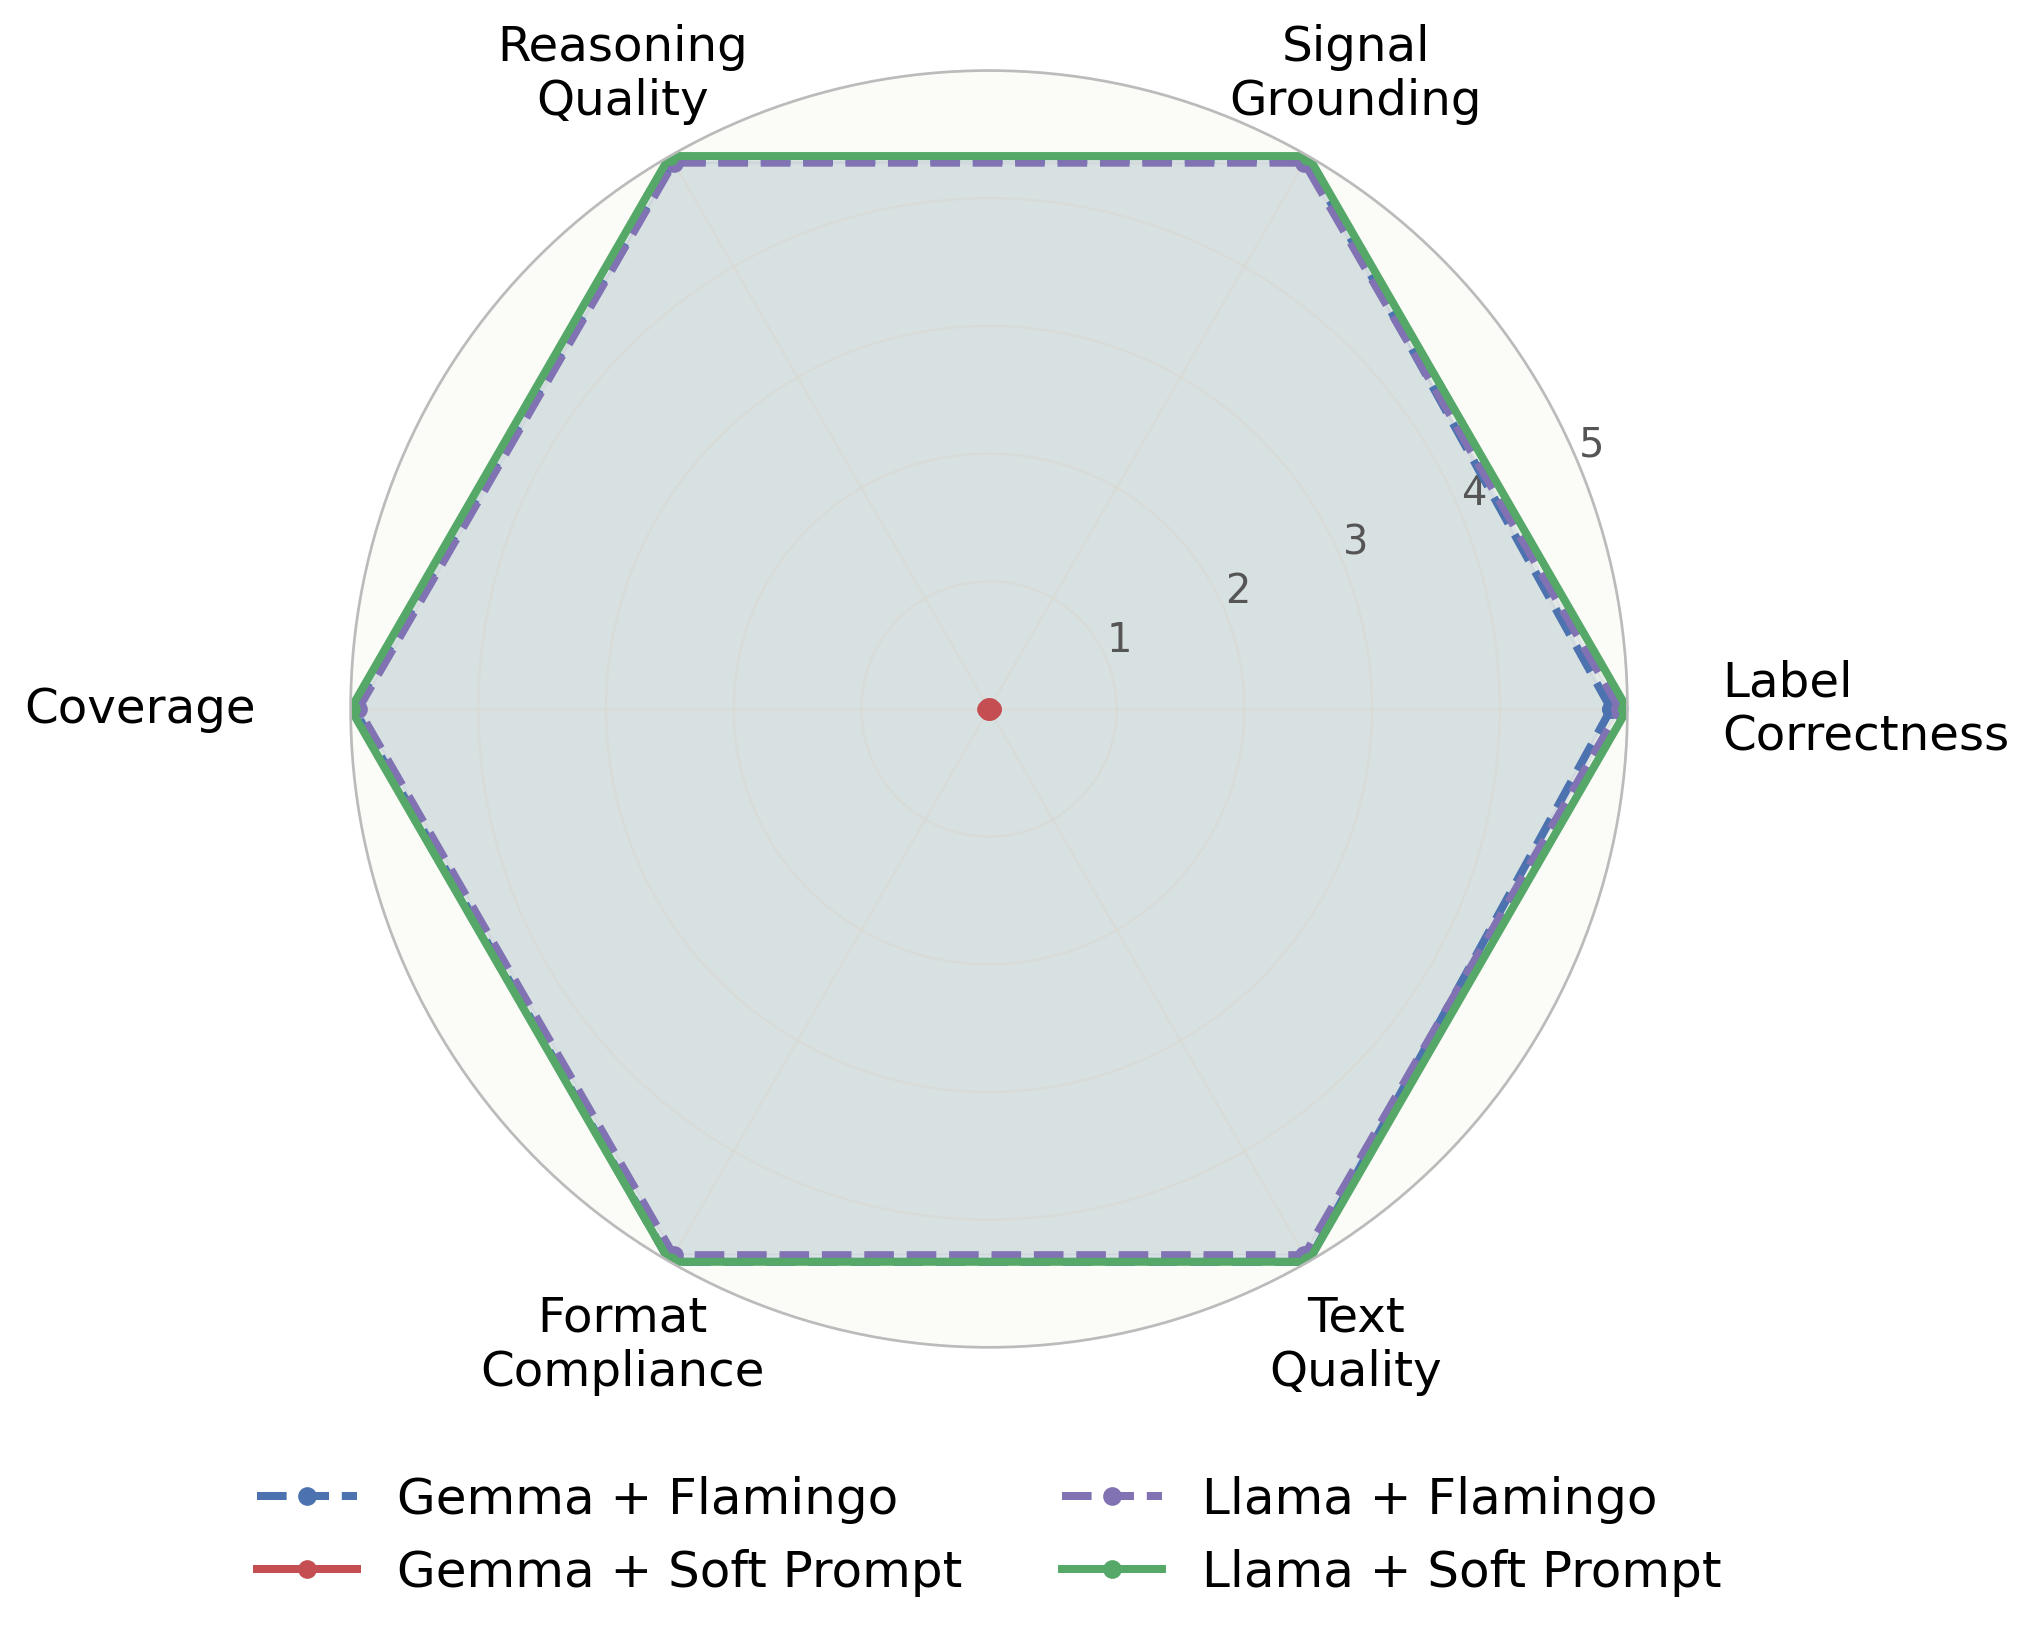

PosixPath('/Users/morsinaldo/Desktop/METROAUTOMOTIVE2026-AutoTSLM/results/article_plots/obd_llm_judge_radar.png')

In [40]:
judge_path = PROJECT_ROOT / 'data' / 'llm_judge_outputs' / 'obd_llm_judge_pointwise_openai.jsonl'
judge_df = pd.read_json(judge_path, lines=True)

criteria = [
    ('label_correctness', 'Label\nCorrectness'),
    ('signal_grounding', 'Signal\nGrounding'),
    ('reasoning_quality', 'Reasoning\nQuality'),
    ('coverage', 'Coverage'),
    ('format_compliance', 'Format\nCompliance'),
    ('text_quality', 'Text\nQuality'),
]

means = judge_df.groupby('system_name')[[key for key, _ in criteria]].mean().reset_index()
means['label'] = means['system_name'].map(SYSTEM_LABELS)
counts = judge_df['system_name'].value_counts().to_dict()

labels = [label for _, label in criteria]
value_cols = [key for key, _ in criteria]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

radar_colors = {
    'gemma_soft_prompt': '#C44E52',
    'gemma_flamingo': '#4C72B0',
    'llama_soft_prompt': '#55A868',
    'llama_flamingo': '#8172B3',
}

fig, ax = plt.subplots(figsize=(7.2, 7.6), subplot_kw={'projection': 'polar'})
line_styles = {
    'gemma_soft_prompt': '-',
    'gemma_flamingo': '--',
    'llama_soft_prompt': '-',
    'llama_flamingo': '--',
}

# Separate perfectly overlapping polygons slightly so all systems remain visible.
value_patterns = means[value_cols].round(6).apply(tuple, axis=1)
offsets = np.zeros(len(means))
for _, dup_idx in value_patterns.groupby(value_patterns).groups.items():
    dup_idx = list(dup_idx)
    if len(dup_idx) == 1:
        continue
    centered = np.linspace(-0.06, 0.06, len(dup_idx))
    for idx, offset in zip(dup_idx, centered):
        offsets[idx] = offset

for idx, row in enumerate(means.itertuples(index=False)):
    base_values = np.array([getattr(row, col) for col in value_cols], dtype=float)
    values = np.clip(base_values + offsets[idx], 0.02, 5.0)
    values = values.tolist() + [values[0]]
    color = radar_colors[row.system_name]
    ax.plot(
        angles,
        values,
        color=color,
        linewidth=2.4,
        linestyle=line_styles[row.system_name],
        marker='o',
        markersize=4.6,
        label=f"{row.label}",
    )
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.tick_params(axis='x', pad=18)
ax.set_xticklabels(labels, fontsize=14.5)

for text, angle in zip(ax.get_xticklabels(), angles[:-1]):
    angle_deg = np.degrees(angle)
    if angle_deg < 1 or angle_deg > 359:
        text.set_horizontalalignment('left')
    elif 0 < angle_deg < 180:
        text.set_horizontalalignment('left')
    elif angle_deg > 180:
        text.set_horizontalalignment('right')

ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=12, color='#555555')
ax.spines['polar'].set_color('#BBBBBB')

legend = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.23), frameon=False, ncol=2)
for text in ax.get_xticklabels():
    text.set_horizontalalignment('center')

fig.subplots_adjust(bottom=0.26, top=0.96)

xticklabels = ax.get_xticklabels()
for i, text in enumerate(xticklabels):
    text.set_horizontalalignment('center')

xticklabels[0].set_horizontalalignment('left')   # Label Correctness
xticklabels[3].set_horizontalalignment('right')  # Coverage

judge_radar_path = ARTICLE_PLOT_DIR / 'obd_llm_judge_radar.png'
fig.savefig(judge_radar_path, dpi=240, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(judge_radar_path)))
judge_radar_path

## 4. Raspberry Pi 5 Resource-Focused Plot

In [5]:
rpi_base = PROJECT_ROOT / 'results' / 'raspberry_pi_inference'
rpi_runs = [
    {'dir': 'obd_soft_prompt_gemma_3_270m_test_20260312T123359Z', 'label': 'Gemma + Soft Prompt', 'approach': 'Soft Prompt', 'family': 'Gemma 3 270M'},
    {'dir': 'obd_flamingo_gemma_3_270m_test_20260312T220802Z', 'label': 'Gemma + Flamingo', 'approach': 'Flamingo', 'family': 'Gemma 3 270M'},
    {'dir': 'obd_soft_prompt_llama_3_2_1b_test_20260312T153715Z', 'label': 'Llama + Soft Prompt', 'approach': 'Soft Prompt', 'family': 'Llama 3.2 1B'},
]

rpi_rows = []
for run in rpi_runs:
    payload = json.loads((rpi_base / run['dir'] / 'summary.json').read_text(encoding='utf-8'))
    sys = payload['system_metrics_summary']
    rpi_rows.append({
        'label': run['label'],
        'approach': run['approach'],
        'family': run['family'],
        'latency_s': sys['inference_latency_s_mean'],
        'cpu_mean': sys['process_cpu_percent_mean'],
        'ram_max_pct': sys['system_ram_percent_max'],
        'rss_peak_gib': sys['process_rss_bytes_max'] / (1024 ** 3),
    })

rpi_df = pd.DataFrame(rpi_rows)
label_positions = {
    'Gemma + Soft Prompt': (7, 1.0, 'left'),
    'Gemma + Flamingo': (7, 2.0, 'left'),
    'Llama + Soft Prompt': (-10, 1.2, 'right'),
}

fig, ax = plt.subplots(figsize=(13.4, 7.8))
ax.axhspan(85, 100, color='#F4D6D6', alpha=0.55, zorder=0)

for row in rpi_df.itertuples(index=False):
    normalized_cpu = row.cpu_mean / 4.0
    size = 120 + 3.1 * normalized_cpu
    color = APPROACH_COLORS[row.approach]
    marker = FAMILY_MARKERS[row.family]
    ax.scatter(row.latency_s, row.ram_max_pct, s=size, color=color, marker=marker, alpha=0.82, edgecolor='#2B2B2B', linewidth=1.15, zorder=4)
    dx, dy, align = label_positions[row.label]
    ax.text(row.latency_s + dx, row.ram_max_pct + dy, f"{row.label}\nRSS peak {row.rss_peak_gib:.2f} GiB", fontsize=13, color='#2B2B2B', ha=align, va='bottom', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.78))

ax.annotate('Llama + Flamingo\nnot runnable on Raspberry Pi 5\n(out of memory before completion)', xy=(425, 94), xytext=(332, 77.8), fontsize=13, color='#7A1E1E', arrowprops=dict(arrowstyle='->', color='#7A1E1E', lw=1.4), bbox=dict(boxstyle='round,pad=0.35', fc='#FFF4F4', ec='#D8A0A0'))
ax.scatter([425], [94], s=240, marker='X', color='#7A1E1E', linewidth=1.4, zorder=5)

ax.set_xlim(190, 440)
ax.set_ylim(42, 100)
ax.set_xlabel('Mean inference latency per sample (s)', fontsize=15)
ax.set_ylabel('Peak system RAM usage (%)', fontsize=15)
ax.tick_params(labelsize=13)

approach_handles = [plt.Line2D([0], [0], marker='o', color='w', label=name, markerfacecolor=color, markeredgecolor='#2B2B2B', markersize=10) for name, color in APPROACH_COLORS.items()]
family_handles = [plt.Line2D([0], [0], marker=marker, color='#666666', linestyle='', label=family, markersize=9) for family, marker in FAMILY_MARKERS.items()]
cpu_sizes = [120 + 3.1 * 25, 120 + 3.1 * 70, 120 + 3.1 * 95]
cpu_labels = ['~25% (CPU/4)', '~70% (CPU/4)', '~95% (CPU/4)']
size_handles = [plt.scatter([], [], s=size, color='#B8B8B8', edgecolor='#666666', label=label) for size, label in zip(cpu_sizes, cpu_labels)]

legend1 = fig.legend(
    handles=approach_handles,
    loc='lower left',
    bbox_to_anchor=(0.18, 0.10),
    frameon=False,
    ncol=2,
    title='Approach'
)

legend2 = fig.legend(
    handles=family_handles,
    loc='lower right',
    bbox_to_anchor=(0.82, 0.10),
    frameon=False,
    ncol=2,
    title='Backbone'
)

legend3 = fig.legend(
    handles=size_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.00),
    frameon=False,
    ncol=3,
    title='Mean process CPU / 4'
)

for legend in (legend1, legend2, legend3):
    plt.setp(legend.get_title(), fontsize=13)
    for text in legend.get_texts():
        text.set_fontsize(12)

fig.subplots_adjust(bottom=0.28)

rpi_plot_path = ARTICLE_PLOT_DIR / 'raspberry_pi_resource.png'
fig.savefig(rpi_plot_path, dpi=240, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(rpi_plot_path)))
rpi_plot_path

FileNotFoundError: [Errno 2] No such file or directory: '/Users/morsinaldo/Desktop/METROAUTOMOTIVE2026-AutoTSLM/results/raspberry_pi_inference/obd_soft_prompt_gemma_3_270m_test_20260312T123359Z/summary.json'